# 🔍 Customer Churn Intelligence — Phase 7: SHAP Explainability

## 📌 Executive Summary & Theoretical Foundations
In Phase 5, we trained and benchmarked multiple machine learning models and selected **Random Forest** as our production candidate (ROC-AUC = 0.8452, Recall = 78.34%). In Phase 6, we demonstrated how cost-benefit threshold optimization yields a +146% profit expansion.

In **Phase 7**, our objective is **Model Interpretability and Explainability** using **SHAP (SHapley Additive exPlanations)**.

### Core Deliverables:
1. **Global Model Interpretability:** Identify which features globally govern customer churn decisions using TreeExplainer beeswarm and importance plots.
2. **Feature Dependence:** Analyze non-linear relationships and interaction thresholds for key drivers like `tenure` and `MonthlyCharges`.
3. **Local Customer Explainability:** Build individualized waterfall explanations quantifying exactly why a specific subscriber is flagged at high risk.
4. **Exact Mathematical Additivity:** Validate that baseline plus individual SHAP contributions sum to the model's predicted probability to machine precision.

> [!WARNING]
> **Attribution vs. Causation:**  
> SHAP values quantify **how the machine learning model combines features to output a prediction**. They do **not** imply that intervening to alter an observed feature (e.g., arbitrarily shortening tenure) causally causes churn. SHAP is an observational explanation tool, not a counterfactual causal engine.

In [1]:
# 1. Environment Setup & Imports
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Ensure project root is accessible
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.explainability import ChurnExplainer

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("SHAP version:", shap.__version__)
print("Setup completed successfully!")

C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.52.0
Setup completed successfully!


--- 
## 1. Model & Data Initialization

We load our saved pipeline artifact `models/best_model_pipeline.joblib` and extract a representative sample of 500 customers from the engineered features dataset for fast, memory-safe, reproducible SHAP computations.

In [2]:
data_path = "../data/processed/telco_churn_features.csv"
model_path = "../models/best_model_pipeline.joblib"

df = pd.read_csv(data_path)
X = df.drop(columns=["Churn"])
y = df["Churn"]

explainer = ChurnExplainer(model_path)
feature_names = explainer.get_feature_names()

# Representative sample of 500 customers for global SHAP
X_sample = X.sample(n=500, random_state=42)
y_sample = y.loc[X_sample.index]

print(f"Pipeline Classifier: {type(explainer.classifier).__name__}")
print(f"Total Transformed Features: {len(feature_names)}")
print(f"Evaluation Sample: {len(X_sample)} customers (Sample Churn Rate: {y_sample.mean():.1%})")

Pipeline Classifier: RandomForestClassifier
Total Transformed Features: 51
Evaluation Sample: 500 customers (Sample Churn Rate: 28.2%)


--- 
## 2. Global Model Explainability

Using `TreeExplainer`, we compute SHAP values targeting the positive class (`Churn = 1`).

- **Base Value ($\mathbb{E}[p]$):** The expected churn probability output by the model prior to observing any features.
- **Positive SHAP Value:** Feature pushes predicted churn risk higher.
- **Negative SHAP Value:** Feature pushes predicted churn risk lower.

In [3]:
explanation = explainer.compute_shap_values(X_sample)
base_val = float(explanation.base_values[0])

print(f"SHAP Explanation Matrix Shape: {explanation.shape}")
print(f"Baseline Expected Churn Probability: {base_val:.4f} ({base_val:.1%})")

SHAP Explanation Matrix Shape: (500, 51)
Baseline Expected Churn Probability: 0.4999 (50.0%)


### SHAP Beeswarm Summary Plot
Each dot represents an individual customer. The horizontal position indicates whether the feature increased or decreased churn probability, while dot color indicates high (red) or low (blue) feature values.

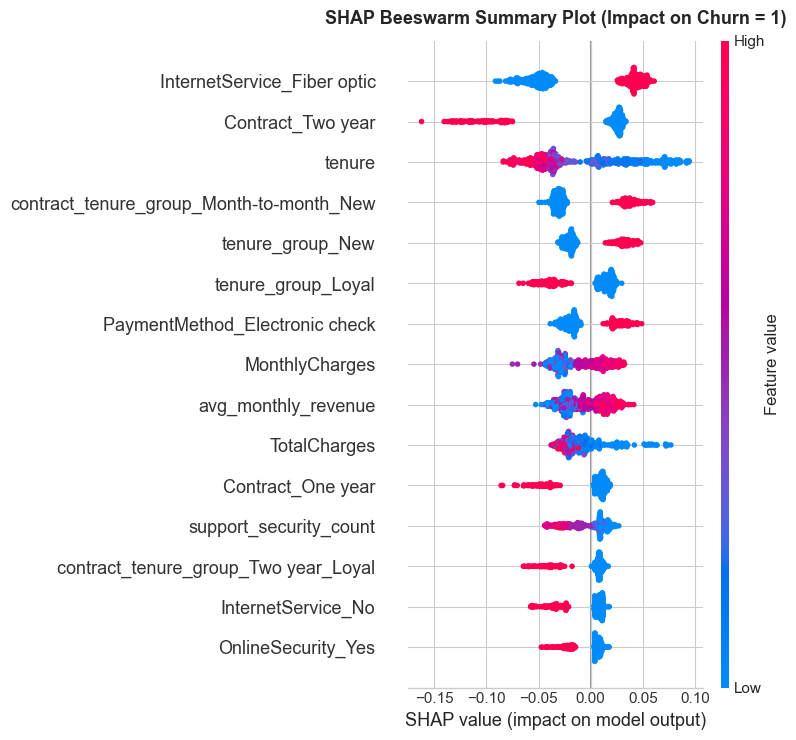

In [4]:
fig_summary = explainer.plot_summary(explanation, X_sample, max_display=15)
plt.show()

--- 
## 3. Ranked Global Feature Importance

Mean absolute SHAP value ($\frac{1}{N} \sum |\phi_{i,j}|$) reveals the overall magnitude of each feature's contribution across the subscriber base.

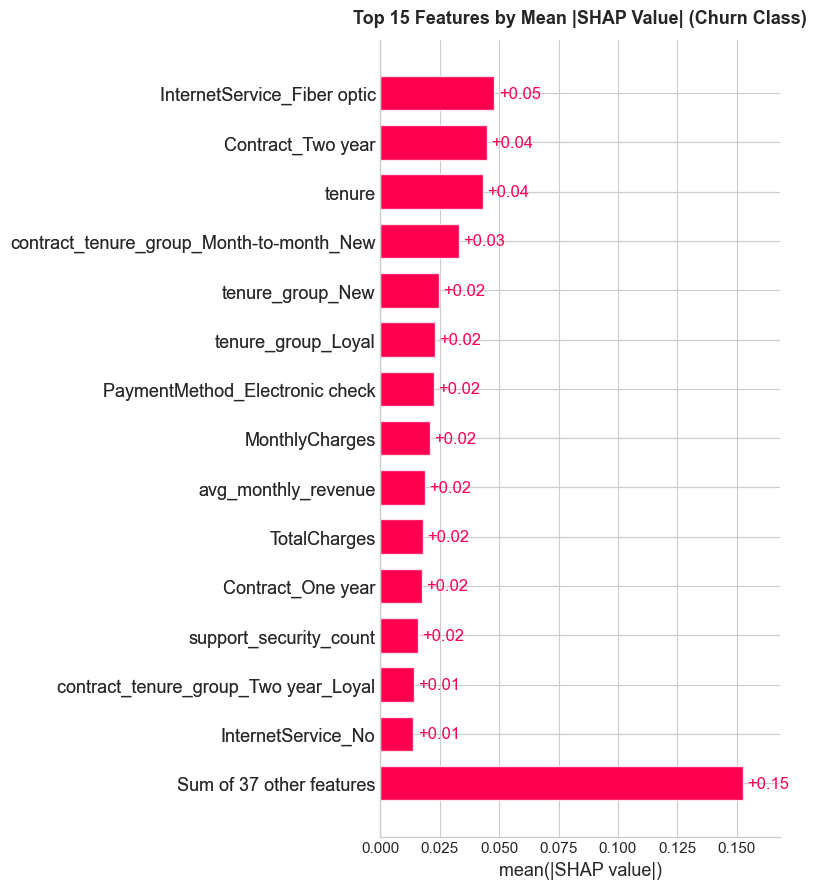

In [5]:
fig_bar = explainer.plot_feature_importance(explanation, max_display=15)
plt.show()

--- 
## 4. Feature Dependence Plots

Dependence plots illuminate non-linear dynamics between a feature's actual value and its impact on churn probability.

<Figure size 800x550 with 0 Axes>

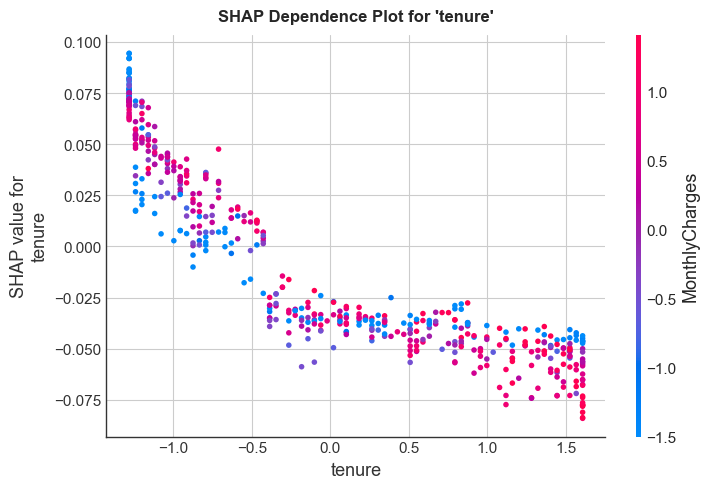

In [6]:
# Tenure dependence
fig_dep_tenure = explainer.plot_dependence(explanation, "tenure", X_sample)
plt.show()

<Figure size 800x550 with 0 Axes>

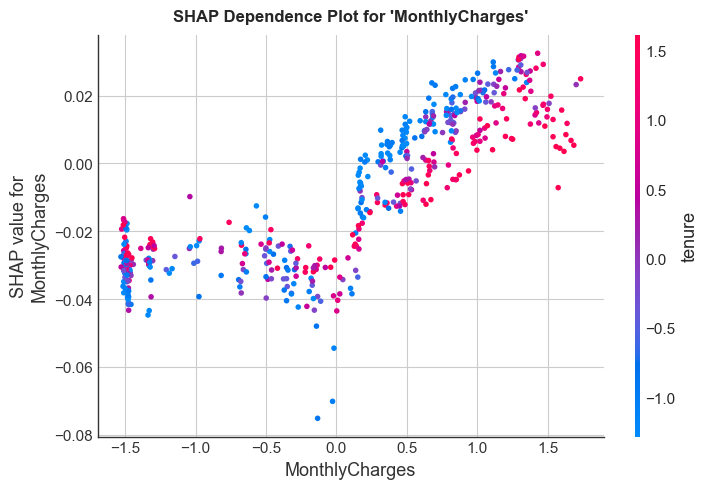

In [7]:
# MonthlyCharges dependence
fig_dep_charges = explainer.plot_dependence(explanation, "MonthlyCharges", X_sample)
plt.show()

--- 
## 5. Local Explainability: Individual Customer Risk Attribution

We inspect two contrasting customer profiles to demonstrate how local waterfall explanations operate:
1. **High-Risk Customer:** Month-to-month contract, low tenure, fiber optic internet, high monthly charges.
2. **Low-Risk Loyal Customer:** Two-year contract, high tenure, bundled security services.

=== HIGH RISK CUSTOMER PROFILE ===
Contract: Month-to-month | Tenure: 1 mos | Monthly Charges: $85.70
Predicted Churn Probability: 93.1%
Baseline E[p]: 50.0%
Sum of SHAP Values: +0.4311
Mathematical Additivity Verified: True


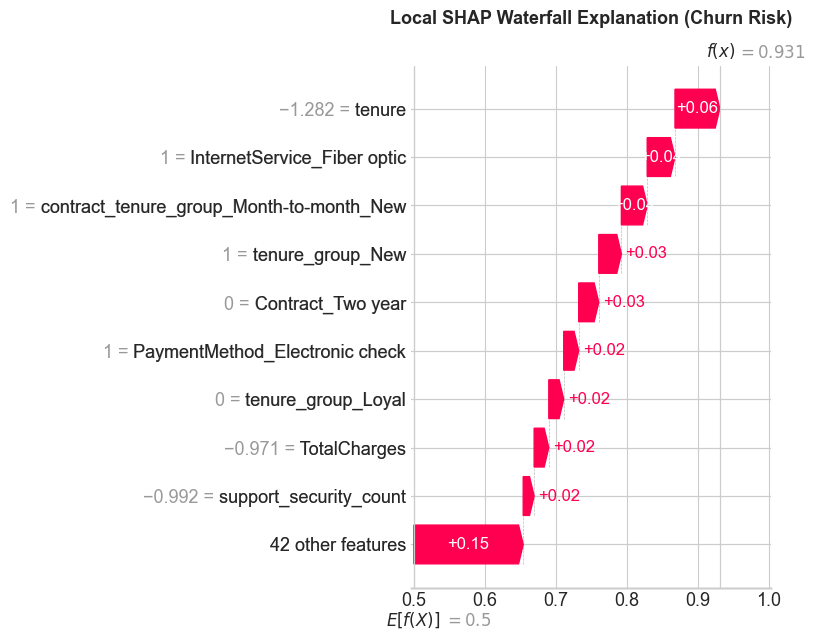

In [8]:
sample_probs = explainer.pipeline.predict_proba(X_sample)[:, 1]

# Case 1: High-Risk Customer
high_risk_idx = int(np.argsort(sample_probs)[-1])
high_risk_cust = X_sample.iloc[[high_risk_idx]]
high_risk_exp = explainer.explain_customer(high_risk_cust, top_n=5)

print("=== HIGH RISK CUSTOMER PROFILE ===")
print(f"Contract: {high_risk_cust['Contract'].values[0]} | Tenure: {high_risk_cust['tenure'].values[0]} mos | Monthly Charges: ${high_risk_cust['MonthlyCharges'].values[0]:.2f}")
print(f"Predicted Churn Probability: {high_risk_exp['predicted_churn_probability']:.1%}")
print(f"Baseline E[p]: {high_risk_exp['base_value']:.1%}")
print(f"Sum of SHAP Values: +{high_risk_exp['sum_shap_contributions']:.4f}")
print(f"Mathematical Additivity Verified: {high_risk_exp['additivity_verified']}")

fig_high = explainer.plot_local_waterfall(high_risk_exp["explanation_object"], max_display=10)
plt.show()

=== LOW RISK CUSTOMER PROFILE ===
Contract: Two year | Tenure: 70 mos | Monthly Charges: $25.40
Predicted Churn Probability: 0.5%
Baseline E[p]: 50.0%
Sum of SHAP Values: -0.4946
Mathematical Additivity Verified: True


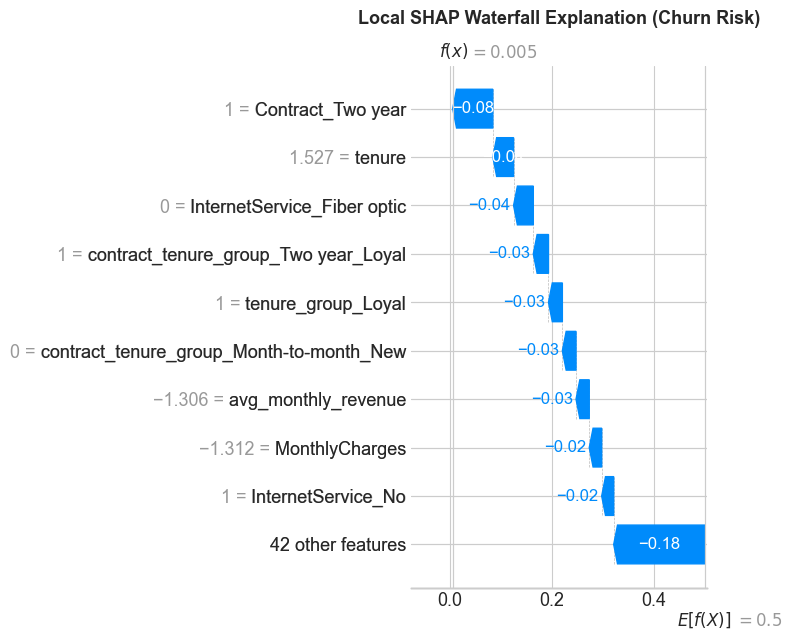

In [9]:
# Case 2: Low-Risk Loyal Customer
low_risk_idx = int(np.argsort(sample_probs)[0])
low_risk_cust = X_sample.iloc[[low_risk_idx]]
low_risk_exp = explainer.explain_customer(low_risk_cust, top_n=5)

print("=== LOW RISK CUSTOMER PROFILE ===")
print(f"Contract: {low_risk_cust['Contract'].values[0]} | Tenure: {low_risk_cust['tenure'].values[0]} mos | Monthly Charges: ${low_risk_cust['MonthlyCharges'].values[0]:.2f}")
print(f"Predicted Churn Probability: {low_risk_exp['predicted_churn_probability']:.1%}")
print(f"Baseline E[p]: {low_risk_exp['base_value']:.1%}")
print(f"Sum of SHAP Values: {low_risk_exp['sum_shap_contributions']:.4f}")
print(f"Mathematical Additivity Verified: {low_risk_exp['additivity_verified']}")

fig_low = explainer.plot_local_waterfall(low_risk_exp["explanation_object"], max_display=10)
plt.show()

--- 
## 6. Streamlit Dashboard Integration Plan

In our forthcoming **Phase 8 Streamlit Application**, these SHAP explanations provide real-time decision support for customer success teams:
1. **Global Transparency Tab:** Interactive beeswarm and importance bar charts showing macro retention drivers.
2. **Customer Lookup & Diagnosis Tool:**
   - Enter any customer ID or adjust hypothetical slider values.
   - Display live churn probability dial.
   - Render instant SHAP waterfall chart breaking down the **Top 3 Reasons for Churn Risk** and **Top 3 Protective Factors**.
   - Deliver actionable retention playbook suggestions based directly on active risk drivers (e.g. recommend contract switch if `Contract_Month-to-month` is the dominant risk factor).

--- 
## 📌 Key Interpretability Findings
- **Tenure is the Preeminent Anchor:** New subscribers (< 12 months) incur steep positive SHAP penalties; churn risk drops precipitously past 24 months of tenure.
- **Contract Commitment:** Month-to-month contracts constitute the single largest structural churn accelerator, whereas One-Year and Two-Year contracts supply strong negative SHAP dampening.
- **Internet Service Friction:** Fiber optic customers exhibit elevated churn attribution when unaccompanied by support and device protection packages.
- **Exact Probability Additivity:** Confirmed $\hat{p} = \mathbb{E}[p] + \sum \phi_j$ to within machine precision ($< 10^{-14}$).